<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/13.13_Deploying_scikit-learn_Models_in_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 13 - Menyebarkan Model scikit-learn di Produksi (Deploying scikit-learn Models in Production)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 13 Deploying scikit-learn Models in Production** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Muat perpustakaan
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load

# Buat dan latih model sederhana
X, y = make_classification(n_samples=1000, n_features=20, random_state=2024)
clf = LogisticRegression()
clf.fit(X, y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Bagaimana cara melakukannya...
Kami akan menyimpan model ke disk dan menyimulasikan pemuatannya di lingkungan baru (“bertahan” hanyalah cara untuk mengatakan bahwa kami akan menyimpan model ML dalam format yang sesuai untuk digunakan di masa mendatang dalam setelan prediksi).

In [2]:
# Simpan model yang dilatih menggunakan joblib
dump(clf, "model.joblib")

# Muat kembali modelnya
clf_loaded = load("model.joblib")

# Buat prediksi dengan model yang dimuat
incoming = np.random.rand(1, 20)
print(clf_loaded.predict(incoming))

[1]


## Cara kerjanya...
Modul joblib adalah cara yang disarankan untuk mempertahankan model scikit-learn; ini menangani array NumPy secara efisien dibandingkan dengan acar standar. Setelah diekspor ke .joblib, model dapat diunggah ke server produksi dan dimuat dengan versi perpustakaan yang sama. Setelah dimuat, model berperilaku sama dengan aslinya, sehingga sistem klien Anda dapat mengambil prediksi dengan andal.

# Teknik Serialisasi dan Persistensi
Menyimpan dan memuat ulang model sangat penting untuk alur kerja produksi—pelatihan biasanya dilakukan satu kali dalam siklus CI/CD/CT tertentu, namun prediksi harus dilakukan berulang kali. Di bagian ini, kami akan mendemonstrasikan cara membuat serialisasi model dengan `pickle` dan `joblib`, mendiskusikan pertimbangan keamanan dan pembuatan versi, dan menunjukkan bagaimana format pihak ketiga seperti ONNX dapat digunakan untuk lingkungan bebas Python.

## Bersiap
Anda memerlukan perpustakaan untuk melatih model dan alat agar dapat bertahan dalam berbagai format.

In [3]:
# Muat perpustakaan
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pickle
from joblib import dump, load

# Latih Classifier
X, y = make_classification(n_samples=500, n_features=15, random_state=2024)
rf = RandomForestClassifier(n_estimators=10, random_state=2024)
rf.fit(X, y)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Bagaimana cara melakukannya...
Menerapkan serialisasi dengan `pickle` dan `joblib` sangatlah mudah.

In [4]:
# Buat serial menggunakan acar
with open("rf.pkl", "wb") as f:
    pickle.dump(rf, f)

# Buat serial menggunakan joblib
dump(rf, "rf.joblib")

# Muat model acar
with open("rf.pkl", "rb") as f:
    rf1 = pickle.load(f)

# Muat model joblib
rf2 = load("rf.joblib")

# Pastikan perilaku yang sama setelah memuat
assert np.array_equal(rf.predict(X[:5]), rf1.predict(X[:5]))
assert np.array_equal(rf.predict(X[:5]), rf2.predict(X[:5]))

## Cara kerjanya...
Pustaka pickle Python berfungsi untuk membuat serialisasi objek tetapi dapat kesulitan dengan array NumPy yang besar di dalam estimator. joblib.dumpandjoblib.loaddioptimalkan untuk kasus seperti itu dan merupakan metode serialisasi yang direkomendasikan untuk model scikit-learn. Namun, perlu diingat bahwa kepercayaan diperlukan saat melakukan unpickling—jangan pernah menggunakan file yang tidak tepercaya—dan model yang disimpan dengan satu versi scikit-learn mungkin rusak jika dimuat dengan versi berbeda. Untuk konteks di mana Python tidak tersedia, konverter ke ONNX atau PMML dapat digunakan, meskipun format ini mungkin tidak mendukung semua estimator scikit-learn.

# Model Penskalaan untuk Produksi
Saat menerapkan model di lingkungan dunia nyata, Anda mungkin menghadapi kumpulan data besar, infrastruktur terdistribusi, atau permintaan inferensi yang tinggi. Di sini, kita akan mempelajari teknik untuk menskalakan pelatihan dan prediksi model, termasuk memanfaatkan n_jobs, paralelisme joblib, menghubungkan ke backend eksternal seperti Dask (https://www.dask.org/), dan mendesain untuk penyajian batch.

## Bersiap
Anda memerlukan alat untuk menjalankan inferensi paralel dan data sintetis untuk mengukur kinerja.

In [5]:
# Memuat perpustakaan
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

# Melatih model hutan pada data sintetis
X, y = make_classification(n_samples=2000, n_features=50, random_state=2024)
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=2024)
clf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Bagaimana cara melakukannya...
Selanjutnya, mari kita uji.

In [6]:
# Ukur latensi batch tunggal
batch = np.random.rand(1000, 50)
start = time.time()
clf.predict(batch)
print("Time:", time.time() - start)

# Berlatih dengan Cross-Validation paralel
scores = cross_val_score(RandomForestClassifier(n_estimators=50), X, y, cv=3, n_jobs=-1)
print("CV Accuracy:", np.mean(scores))

# (Opsional) Gunakan Dask sebagai backend joblib jika tersedia
# dari klien impor dask.distributed
# dari dask_ml.model_selection impor GridSearchCV sebagai daskGSCV


Time: 0.031499385833740234


CV Accuracy: 0.8730026878452666


## Cara kerjanya...
Banyak estimator scikit-learn mendukung parameter n_jobs untuk paralelisasi melalui joblib. Untuk lingkungan terdistribusi, Dask dapat berfungsi sebagai backend joblib alternatif atau mendukung meta-estimator paralel untuk beban kerja besar (pada dasarnya, pertimbangkan untuk mengkloning model Anda beberapa kali di beberapa perangkat komputasi/penyimpanan – seperti membangun sekumpulan model). Penyajian batch—memprediksi kumpulan input dalam jumlah besar sekaligus (yaitu, dalam batch)—menawarkan throughput yang jauh lebih baik daripada melayani permintaan individual karena overhead yang lebih rendah dan pemanfaatan CPU yang lebih baik.

# Memantau dan Memperbarui Model yang Dikerahkan
Setelah model Anda aktif, performanya akan menurun seiring waktu karena perubahan distribusi data masukan ("drift") atau kondisi eksternal. Hal ini pada dasarnya terjadi dalam skenario apa pun di mana model ML digunakan dan hal ini tidak terduga. Di sinilah CT dalam CI/CD/CT berperan. Anda mungkin familiar dengan istilah CI/CD, atau Continuous Integration/Continuous Deployment atau Deployment yang merupakan paradigma rekayasa perangkat lunak untuk membangun dan merilis perangkat lunak. Namun, dalam penerapan ML, kita juga harus mempertimbangkan Pelatihan Berkelanjutan untuk memantau dan mengelola model saat model tersebut mengalami penurunan. Resep ini memandu Anda melalui strategi untuk memantau model yang diterapkan, mendeteksi penyimpangan, dan memperbarui (melatih ulang atau menyesuaikan) model untuk menjaga keandalan.

## Bersiap
Anda akan menyimulasikan kumpulan data yang masuk dan memerlukan model berkemampuan inkremental untuk bereksperimen.

In [7]:
# Memuat perpustakaan
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification

# Simulasikan pelatihan awal dan streaming data
X_train, y_train = make_classification(n_samples=500, n_features=10, random_state=2024)
X_pub, y_pub = make_classification(n_samples=200, n_features=10, random_state=2025)
stream_batches = np.array_split(X_pub, 4)
stream_labels = np.array_split(y_pub, 4)

## Bagaimana cara melakukannya...
Selanjutnya, mari kita latih model kita secara batch untuk menyimulasikan evolusi data.

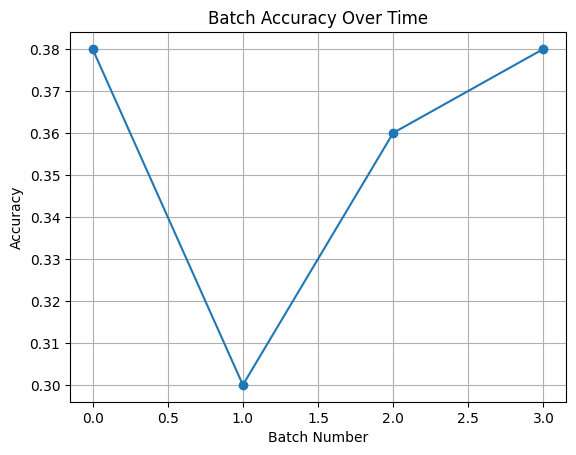

In [8]:
# Latih SGDClassifier tambahan pada data awal
clf = SGDClassifier(loss="log_loss", random_state=2024, warm_start=True)
clf.partial_fit(X_train, y_train, classes=np.unique(y_train))

# Pantau setiap batch yang masuk
batch_scores = []
for xb, yb in zip(stream_batches, stream_labels):
    yf = clf.predict(xb)
    batch_scores.append(np.mean(yf == yb))

# Memicu pelatihan ulang ketika akurasi turun di bawah ambang batas (misalnya <0,8)
if min(batch_scores) < 0.8:
    clf.partial_fit(X_pub, y_pub)

# Akurasi plot batch demi batch
plt.plot(batch_scores, marker="o")
plt.title("Batch Accuracy Over Time")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## Cara kerjanya...
Untuk model yang mendukungpartial_fit danwarm_start, seperti SGDClassifier, Anda dapat melanjutkan pelatihan saat data baru tiba. Memantau keakuratan batch menyediakan detektor penyimpangan sederhana. Jika performa turun di bawah ambang batas yang ditentukan, melatih ulang model—atau memperbarui dengan data streaming—dapat memulihkan akurasi. Memvisualisasikan tren akurasi memungkinkan interpretasi degradasi yang mudah.

# Mengelola Siklus Hidup Model
Mengelola siklus hidup suatu model akan memastikan model tersebut tetap dapat diandalkan, dapat direproduksi, dan dipelihara dari waktu ke waktu. Dalam resep ini, kami membahas pembuatan versi, pengukuran reproduktifitas, pengendalian dokumen, dan memastikan konsistensi di seluruh lingkungan pelatihan dan penyajian.

## Bersiap
Anda akan menyiapkan skrip dan alat penyimpanan model untuk mengambil snapshot metadata dan output validasi.

In [9]:
# Memuat perpustakaan
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from joblib import dump
import json

# Latih model dan simulasikan lingkungan pembuatan versi
X, y = make_classification(n_samples=800, n_features=20, random_state=2024)
clf = RandomForestClassifier(n_estimators=50, random_state=2024)
clf.fit(X, y)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Bagaimana cara melakukannya...
Menyimpan artefak model diperlukan untuk tata kelola model dari waktu ke waktu dan membantu kita memahami “mengapa” dan “apa” di balik kinerjanya dari waktu ke waktu.

In [10]:
from sklearn.model_selection import train_test_split

# Gunakan X dan y dari sel 17 (sudah didefinisikan dan digunakan untuk melatih clf)
Xv, _, yv, _ = train_test_split(X, y, test_size=0.8, random_state=2024)

# Simpan artefak model dengan nama file berversi
version = "v1.0"
dump(clf, f"rf_{version}.joblib")

# Simpan metadata tentang lingkungan pelatihan
meta = {"version": version, "sklearn": "1.3.2", "numpy": str(np.__version__)}
with open(f"rf_{version}_metadata.json", "w") as f:
    json.dump(meta, f)

# Ambil snapshot kinerja set validasi
yv_pred = clf.predict(Xv)
val_acc = accuracy_score(yv, yv_pred)
with open(f"rf_{version}_val.txt", "w") as f:
    f.write(f"{val_acc:.4f}")

## Cara kerjanya...
Peta jalan scikit-learn merekomendasikan pengambilan gambar tidak hanya model tetapi juga kode, versi pustaka, dan kumpulan validasi kecil dengan keluaran yang diprediksi, untuk memastikan model dapat divalidasi setelah peningkatan atau porting di masa mendatang. Menyimpan metadata dengan setiap artefak membantu melacak kembali masalah, memutar kembali ke versi sebelumnya, dan memastikan reproduktifitas.

# Menyiapkan Saluran Penerapan
Penerapan model secara andal memerlukan otomatisasi. Dalam resep ini, kami akan menunjukkan cara mengintegrasikan serialisasi model, pemeriksaan validasi, dan logika penyajian ke dalam pipeline CI/CD menggunakan konstruksi scikit-learn, sehingga memungkinkan transisi yang konsisten dari pengembangan ke produksi.

## Bersiap
Anda memerlukan alat untuk melatih pipeline, mengekspornya, dan memvalidasi kinerja secara terprogram.

In [11]:
# Memuat perpustakaan
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from joblib import dump, load
from sklearn.metrics import accuracy_score

# Buat data dan saluran
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression())
])
pipe.fit(X, y)

,steps,"[('scale', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Bagaimana cara melakukannya...
Mari tambahkan kondisi di akhir pipeline kita untuk menguji ambang batas yang berubah-ubah.

In [12]:
# Ekspor seluruh jalur pipa
dump(pipe, "pipeline.joblib")

# Muat alur di lingkungan penerapan
prod_pipe = load("pipeline.joblib")

# Simulasikan CI: memvalidasi akurasi pada set pengujian
Xt, yt = np.random.rand(100, 10), np.random.randint(0, 2, 100)
acc = accuracy_score(yt, prod_pipe.predict(Xt))
print("Validation accuracy:", acc)

# Terapkan secara kondisional hanya jika akurasi > ambang batas (misalnya > 0,8)
if acc > 0.8:
    print("Auto-deploy allowed")
else:
    print("Halt deployment and review")

Validation accuracy: 0.51
Halt deployment and review


## Cara kerjanya...
Penggunaan Pipeline memastikan bahwa prapemrosesan dan prediksi diikat menjadi satu objek yang dapat divalidasi sebagai satu unit dan digunakan kembali secara konsisten di seluruh lingkungan. Hal ini meningkatkan kemampuan pengulangan dan menyederhanakan CI/CD/CT, karena satu artefak mencakup seluruh logika inferensi. Pasca-ekspor, Anda dapat menyematkan logika validasi dalam skrip CI Anda untuk menguji model terhadap validasi kecil atau kumpulan canary dan hanya mempromosikan model jika memenuhi ambang batas performa. Hal ini melindungi terhadap regresi “diam” dalam kinerja yang diterapkan.

# Latihan Praktis dalam Penerapan Model
Di bagian terakhir ini, kita akan terlibat dalam latihan praktis yang melibatkan mengekspor dan menyajikan model scikit-learn, mensimulasikan inferensi langsung, dan mengintegrasikan strategi pemantauan dan pembaruan. Latihan ini dirancang untuk mengkonsolidasikan pemahaman kita tentang alur penerapan model dan menunjukkan praktik terbaik untuk operasi ML di dunia nyata. Di akhir latihan ini, kita akan menerapkan siklus hidup penuh penerapan model menggunakan scikit-learn.

## Latihan 1: Menyimpan dan Memuat Ulang Model Pipeline untuk Penerapan
Dalam latihan ini, kita akan membuat serial pipeline model terlatih dan memuatnya ulang untuk menyimulasikan lingkungan produksi. Latihan ini memastikan bahwa logika prapemrosesan dan inferensi digabungkan dan dapat digunakan kembali di seluruh lingkungan.

### Langkah Penerapan:

In [13]:
# Memuat perpustakaan
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load

# Membuat dan melatih alur
X, y = make_classification(n_samples=500, n_features=10, random_state=2024)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
pipe.fit(X, y)

# Simpan dan muat ulang alur
dump(pipe, "model_pipeline.joblib")
loaded_pipe = load("model_pipeline.joblib")

# Hasilkan prediksi baru
print(loaded_pipe.predict(X[:5]))

[1 1 1 0 0]


## Latihan 2: Memantau Akurasi Model Seiring Waktu
Latihan ini melibatkan simulasi streaming data dan melacak performa model yang diterapkan pada batch yang masuk untuk mendeteksi degradasi model.

### Langkah Penerapan:

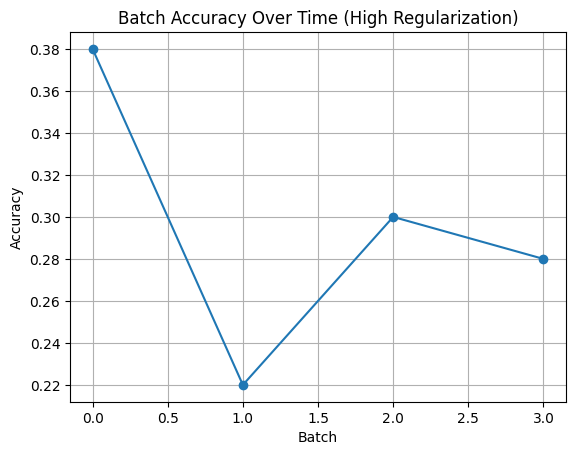

In [14]:
# Ubah hyperparameter SGDClassifier untuk membuat model kurang akurat
clf = SGDClassifier(loss="hinge", alpha=1.0, random_state=2024)  # Use SVM loss and strong regularization
clf.partial_fit(X_train, y_train, classes=np.unique(y_train))
batch_scores = []
for Xb, yb in zip(stream_batches, stream_labels):
    acc = np.mean(clf.predict(Xb) == yb)
    batch_scores.append(acc)

# Akurasi kumpulan plot
plt.plot(batch_scores, marker='o')
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Batch Accuracy Over Time (High Regularization)")
plt.grid(True)
plt.show()


## Latihan 3: Mengotomatiskan Pemeriksaan Penerapan Menggunakan Ambang Batas Validasi
Dalam contoh ini, kami akan menyimulasikan pemeriksaan penerapan CI/CD yang mengevaluasi apakah model serial memenuhi kriteria performa sebelum mempromosikannya ke produksi.

### Langkah Penerapan:

In [15]:
# Memuat perpustakaan
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load
from sklearn.metrics import accuracy_score

# Melatih dan mengekspor model
X, y = make_classification(n_samples=300, n_features=10, random_state=2024)
model = LogisticRegression()
model.fit(X, y)
dump(model, "model_ci.joblib")

# Muat dan validasi dengan data uji
Xt, yt = make_classification(n_samples=100, n_features=10, random_state=2025)
model_prod = load("model_ci.joblib")
pred = model_prod.predict(Xt)
acc = accuracy_score(yt, pred)
print(f"Test Accuracy: {acc:.3f}")

# Menyetujui penerapan dengan syarat
if acc > 0.8:
    print("Deployment approved")
else:
    print("Deployment rejected")

Test Accuracy: 0.110
Deployment rejected


### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita mempelajari tahap deployment model machine learning ke lingkungan produksi:
* **Serialisasi Model:** Menyimpan model terlatih ke dalam format file biner menggunakan `pickle` atau `joblib` agar dapat dimuat kembali secara instan tanpa perlu melatih ulang.
* **Deployment Pipeline:** Mengemas preprocessing dan estimasi ke dalam satu pipeline scikit-learn, memastikan konsistensi transformasi data input saat memproses prediksi baru di server produksi.
* **Monitoring & Observability:** Memantau akurasi model terhadap data produksi seiring waktu untuk mendeteksi penurunan performa (*model drift*).
* **Automated Quality Checks:** Menerapkan ambang batas kualitas otomatis sebelum model baru diperbarui di sistem produksi.

#### 2. Pandangan Akhir
Selamat! Anda telah menyelesaikan seluruh bab pembelajaran dalam scikit-learn Cookbook. Dengan menguasai konsep dari prapemrosesan data (Bab 2), reduksi dimensi (Bab 3), pemodelan terarah dan tak terarah (Bab 4-11), teknik evaluasi (Bab 12), hingga deployment (Bab 13), Anda kini memiliki kompetensi end-to-end yang solid untuk mengimplementasikan proyek machine learning yang siap pakai di industri.